# Telecom X - Análisis de Evasión de Clientes


Has sido contratado como asistente de análisis de datos en Telecom X y formarás parte del proyecto "**Churn de Clientes**". La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

Tu desafío será recopilar, procesar y analizar los datos, utilizando Python y sus principales bibliotecas para extraer información valiosa. A partir de tu análisis, el equipo de Data Science podrá avanzar en modelos predictivos y desarrollar estrategias para reducir la evasión.


## Extracción (E - Extract)

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
# !pip3 install pandas seaborn matplotlib numpy

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_json("TelecomX_Data.json")

In [4]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## Transformación (T - Transform)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [6]:
df.dtypes

customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object

In [7]:
df.describe()

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,0002-ORFBO,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


### Comprobación de incoherencias en los datos

In [8]:
for col in df.select_dtypes(include=["object"]).columns:
    try:
        valores_unicos = df[col].unique()
    except TypeError as e:
        if "unhashable type" in str(e):
            valores_unicos = df[col].astype(str).unique()
        else:
            raise

    print(f"\nColumna: '{col}'")
    print(f"Valores Únicos ({len(valores_unicos)} en total):")

    if len(valores_unicos) > 50:
        print(
            f"Demasiados valores para mostrar ({len(valores_unicos)}). Mostrando los primeros 5: {valores_unicos[:5]}"
        )
    else:
        print(valores_unicos)


Columna: 'customerID'
Valores Únicos (7267 en total):
Demasiados valores para mostrar (7267). Mostrando los primeros 5: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ']

Columna: 'Churn'
Valores Únicos (3 en total):
['No' 'Yes' '']

Columna: 'customer'
Valores Únicos (891 en total):
Demasiados valores para mostrar (891). Mostrando los primeros 5: ["{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}"
 "{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 9}"
 "{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 4}"
 "{'gender': 'Male', 'SeniorCitizen': 1, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 13}"
 "{'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 3}"]

Columna: 'phone'
Valores Únicos (3 en total):
["{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
 "{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}"
 "{'PhoneServi

In [9]:
import ast

json_cols = ["customer", "phone", "internet", "account"]


def safe_literal_eval(x):
    if isinstance(x, str):
        return ast.literal_eval(x.strip())
    return x


for col in json_cols:
    df[col] = df[col].apply(safe_literal_eval)


for col in json_cols:
    if col == "account":
        df_temp = df[col].apply(pd.Series)
        df = pd.concat([df, df_temp], axis=1)
        df = df.drop(columns=[col])

        df_charges = df["Charges"].apply(pd.Series)
        df = pd.concat([df, df_charges], axis=1)
        df = df.drop(columns=["Charges"])
    else:
        df_temp = df[col].apply(pd.Series)
        df = pd.concat([df, df_temp], axis=1)
        df = df.drop(columns=[col])

print("Primeras 5 filas del DataFrame final:")
print(df.head())

Primeras 5 filas del DataFrame final:
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female              0     Yes        Yes       9   
1  0003-MKNFE    No    Male              0      No         No       9   
2  0004-TLHLJ   Yes    Male              0      No         No       4   
3  0011-IGKFF   Yes    Male              1     Yes         No      13   
4  0013-EXCHZ   Yes  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes         Yes      

In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [11]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [12]:
df.isnull().sum()

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64

In [13]:
df.replace("", np.nan, inplace=True)
df.replace(" ", np.nan, inplace=True)

df.isnull().sum()

customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Monthly               0
Total                11
dtype: int64

In [14]:
df.dropna(subset=["Churn"], inplace=True)
print(f"Filas eliminadas en 'Churn'. Filas restantes: {len(df)}")

df["Total"] = df["Total"].fillna(0)
print("Valores nulos en 'Total' con 0.")

print("\nVerificación de valores ausentes después de las correcciones:")
print(df[["Churn", "Total"]].isnull().sum())

Filas eliminadas en 'Churn'. Filas restantes: 7043
Valores nulos en 'Total' con 0.

Verificación de valores ausentes después de las correcciones:
Churn    0
Total    0
dtype: int64


### Columna de cuentas diarias

Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

In [15]:
dias_promedio_mes = 365 / 12

df["Cuentas_Diarias"] = df["Monthly"] / dias_promedio_mes
print(df[["Monthly", "Cuentas_Diarias"]].head())

   Monthly  Cuentas_Diarias
0     65.6         2.156712
1     59.9         1.969315
2     73.9         2.429589
3     98.0         3.221918
4     83.9         2.758356


### Estandarización y transformación de datos 

La **estandarización y transformación de datos** es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más **consistente, comprensible y adecuada para el análisis**. Durante esta fase, por ejemplo, puedes convertir valores textuales como **"Sí" y "No"** en valores binarios **(1 y 0)**, lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

Además,**traducir o renombrar columnas y datos** hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos. Aunque no es un paso obligatorio, puede mejorar significativamente la **claridad y comunicación de los resultados**, facilitando la interpretación y evitando confusiones, especialmente al compartir información con **stakeholders no técnicos**.

In [16]:
mapeo_binario = {
    "Yes": 1,
    "No": 0,
    "Female": 0,
    "Male": 1,
    "No internet service": 0,
    "No phone service": 0,
}

columnas_binarias = [
    "Churn",
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
]

for col in columnas_binarias:
    df[col] = df[col].replace(mapeo_binario).astype(int)

df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)


columnas_categoricas = [
    "InternetService",
    "Contract",
    "PaymentMethod",
]

df_dummies = pd.get_dummies(
    df[columnas_categoricas], drop_first=True, prefix=columnas_categoricas
)

df = pd.concat([df, df_dummies], axis=1)
df = df.drop(columns=columnas_categoricas)

renombrar_columnas = {
    # Columnas Binarias (Mapeadas a 1/0)
    "gender": "Genero",
    "SeniorCitizen": "Tercera_Edad",
    "tenure": "Permanencia_Meses",
    "Partner": "Tiene_Pareja",
    "Dependents": "Tiene_Dependientes",
    "PhoneService": "Servicio_Telefono",
    # Columnas de Servicios
    "MultipleLines": "Multiples_Lineas",
    "OnlineSecurity": "Seguridad_Online",
    "OnlineBackup": "Respaldo_Online",
    "DeviceProtection": "Proteccion_Dispositivo",
    "TechSupport": "Soporte_Tecnico",
    "StreamingTV": "Streaming_TV",
    "StreamingMovies": "Streaming_Peliculas",
    "PaperlessBilling": "Facturacion_Sin_Papel",
    # Columnas Numéricas
    "Total": "Cargos_Totales",
    "Monthly": "Cargos_Mensuales",
    "Cuentas_Diarias": "Cargos_Diarios",
    # Columnas One-Hot generadas
    "InternetService_Fiber optic": "Internet_Fibra_Optica",
    "InternetService_No": "Internet_No_Servicio",
    "Contract_One year": "Contrato_Un_Año",
    "Contract_Two year": "Contrato_Dos_Años",
    "PaymentMethod_Electronic check": "Pago_Cheque_Electronico",
    "PaymentMethod_Mailed check": "Pago_Cheque_Correo",
    "PaymentMethod_Credit card (automatic)": "Pago_Tarjeta_Credito",
    "PaymentMethod_Bank transfer (automatic)": "Pago_Transferencia_Bancaria",
}

renombrar_final = {k: v for k, v in renombrar_columnas.items() if k in df.columns}

df.rename(columns=renombrar_final, inplace=True)

print(df[["Churn", "Genero", "Tiene_Pareja", "Servicio_Telefono"]].head())

   Churn  Genero  Tiene_Pareja  Servicio_Telefono
0      0       0             1                  1
1      0       1             0                  1
2      1       1             0                  1
3      1       1             1                  1
4      1       0             1                  1


## Carga y análisis (L - Load & Analysis)

#### Análisis Descriptivo de los Datos
 Calculando métricas como **media**, **mediana**, **desviación estándar** y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.


In [17]:
df.describe()

,Churn,Genero,Tercera_Edad,Tiene_Pareja,Tiene_Dependientes,Permanencia_Meses,Servicio_Telefono,Multiples_Lineas,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Facturacion_Sin_Papel,Cargos_Mensuales,Cargos_Diarios
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2.129152
std,0.441561,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,0.989262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.600000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,1.167123
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,2.312877
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,2.953973
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,3.904110


In [18]:
cols = ["Cargos_Totales", "Cargos_Mensuales", "Cargos_Diarios", "Permanencia_Meses"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(0)

media_cargos_totales = df["Cargos_Totales"].mean()
media_cargos_mensuales = df["Cargos_Mensuales"].mean()
media_cargos_diarios = df["Cargos_Diarios"].mean()
media_permanencia = df["Permanencia_Meses"].mean()

print(f"Media de Cargos Mensuales: {media_cargos_totales:.2f}")
print(f"Media de Cargos Mensuales: {media_cargos_mensuales:.2f}")
print(f"Media de Cargos Mensuales: {media_cargos_diarios:.2f}")
print(f"Media de Cargos Mensuales: {media_permanencia:.2f}")

Media de Cargos Mensuales: 2279.73
Media de Cargos Mensuales: 64.76
Media de Cargos Mensuales: 2.13
Media de Cargos Mensuales: 32.37


In [19]:
mediana_cargos_totales = df["Cargos_Totales"].median()
mediana_cargos_mensuales = df["Cargos_Mensuales"].median()
mediana_cargos_diarios = df["Cargos_Diarios"].median()
mediana_permanencia = df["Permanencia_Meses"].median()

print(f"Mediana de Cargos Mensuales: {mediana_cargos_totales:.2f}")
print(f"Mediana de Cargos Mensuales: {mediana_cargos_mensuales:.2f}")
print(f"Mediana de Cargos Mensuales: {mediana_cargos_diarios:.2f}")
print(f"Mediana de Cargos Mensuales: {mediana_permanencia:.2f}")

Mediana de Cargos Mensuales: 1394.55
Mediana de Cargos Mensuales: 70.35
Mediana de Cargos Mensuales: 2.31
Mediana de Cargos Mensuales: 29.00


In [20]:
cols = ["Cargos_Totales", "Cargos_Mensuales", "Cargos_Diarios", "Permanencia_Meses"]
desviacion_estandar = df[cols].std()

print(desviacion_estandar)

Cargos_Totales       2266.794470
Cargos_Mensuales       30.090047
Cargos_Diarios          0.989262
Permanencia_Meses      24.559481
dtype: float64


#### Distribución de evasión
En este paso, el objetivo es comprender cómo está distribuida la variable "churn" **(evasión)** entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

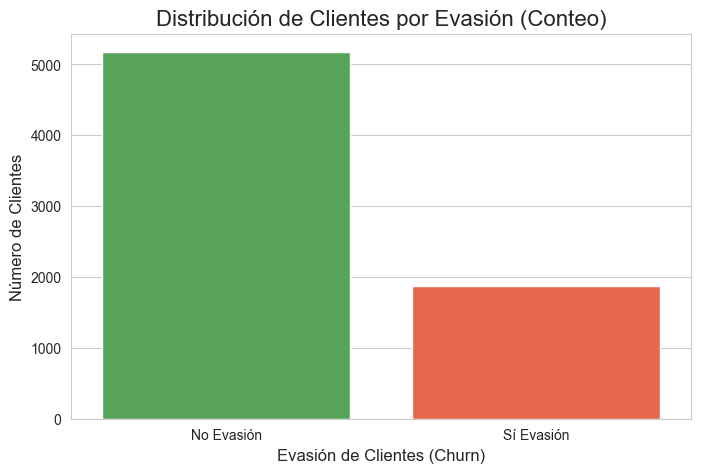

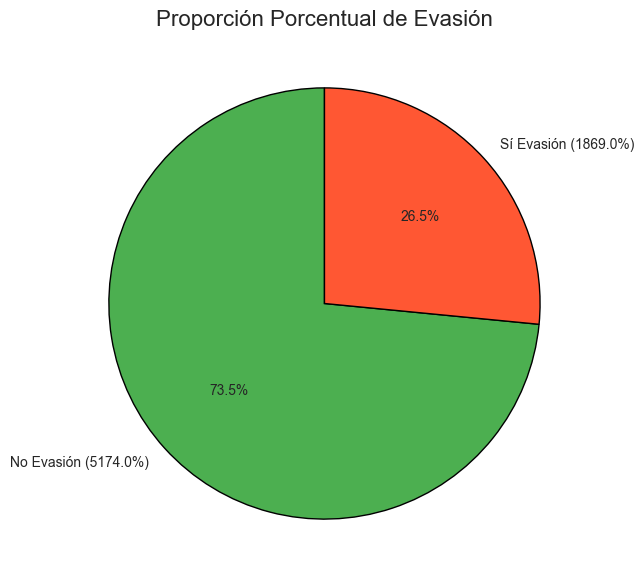

In [21]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = [10, 5]

df["Etiqueta_Churn"] = df["Churn"].map({0: "No Evasión", 1: "Sí Evasión"})

plt.figure(figsize=(8, 5))
sns.countplot(x="Etiqueta_Churn", data=df, palette=["#4CAF50", "#FF5733"])
plt.title("Distribución de Clientes por Evasión (Conteo)", fontsize=16)
plt.xlabel("Evasión de Clientes (Churn)", fontsize=12)
plt.ylabel("Número de Clientes", fontsize=12)
plt.show()

conteo_churn = df["Etiqueta_Churn"].value_counts()
porcentajes = conteo_churn.values / conteo_churn.sum() * 100
etiquetas = [f"{k} ({v/100:.1%})" for k, v in conteo_churn.items()]

plt.figure(figsize=(7, 7))
plt.pie(
    conteo_churn.values,
    labels=etiquetas,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50", "#FF5733"],
    wedgeprops={"edgecolor": "black"},
)
plt.title("Proporción Porcentual de Evasión", fontsize=16)
plt.show()

df = df.drop(columns=["Etiqueta_Churn"])

#### Recuento de evasión por variables categóricas
Este análisis puede revelar **patrones interesantes**, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a **orientar acciones estratégicas**.

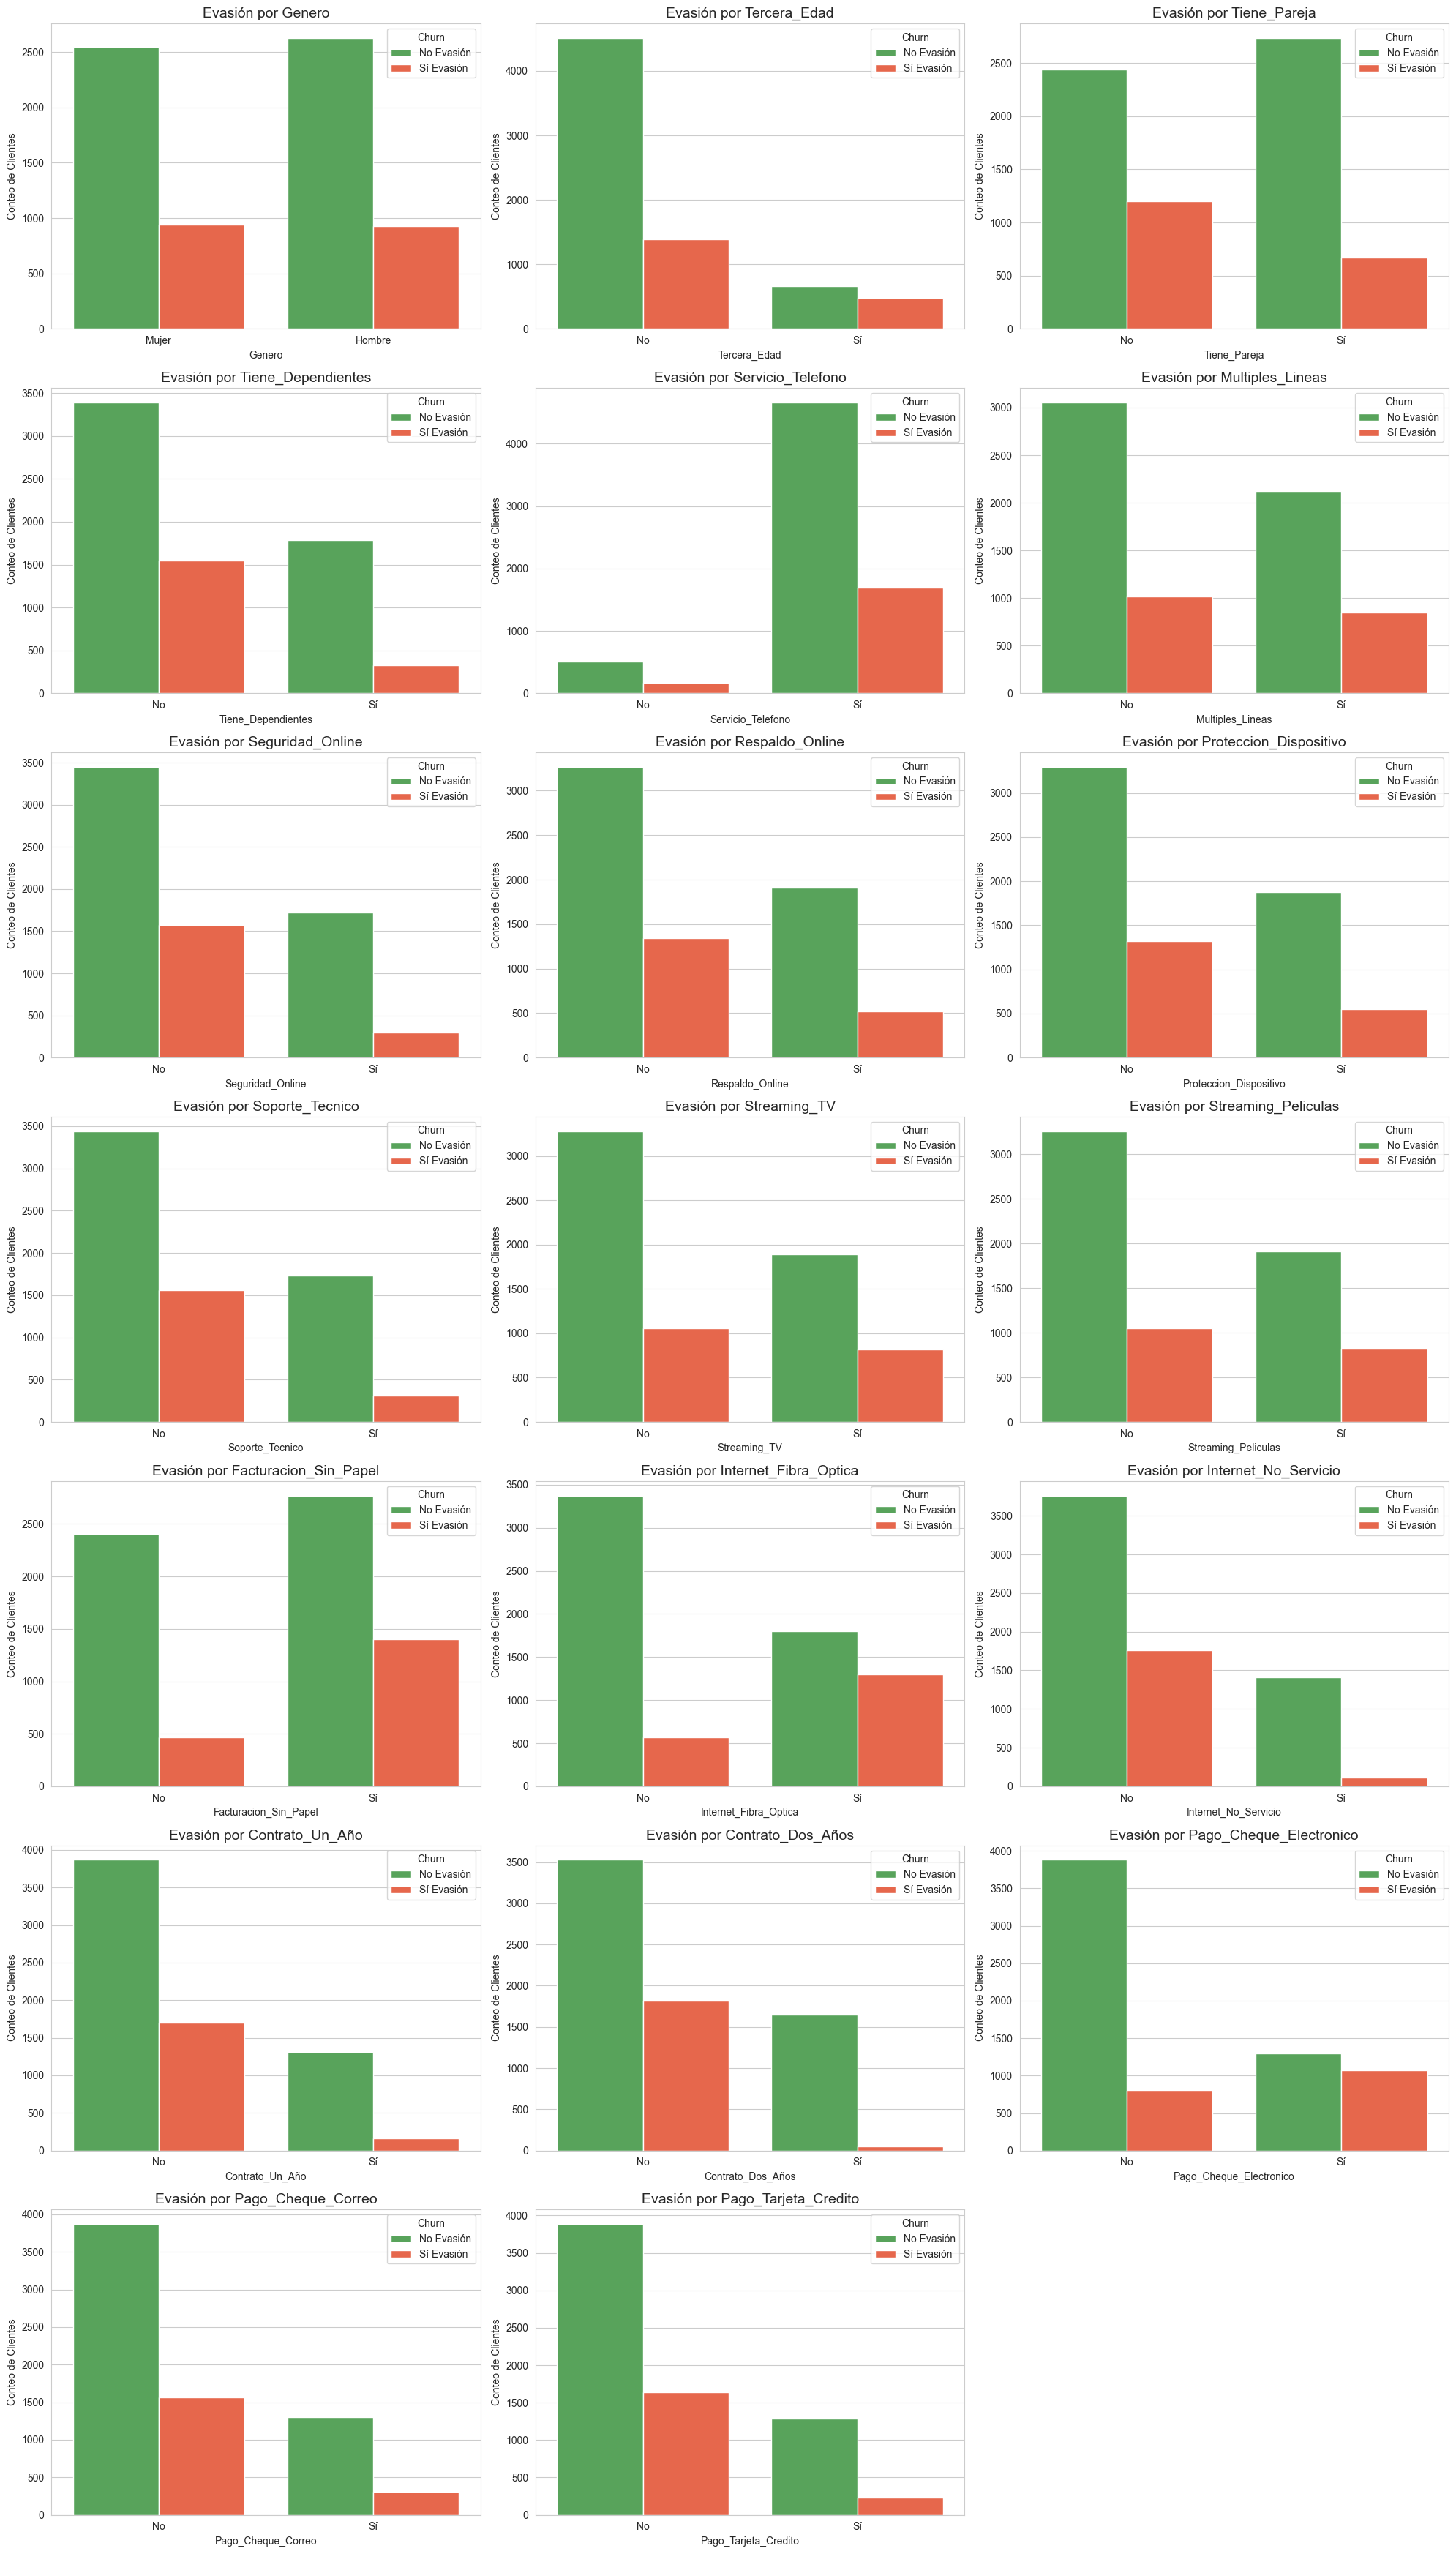

In [22]:
columnas_segmentacion = [
    "Genero",  # 1 = Hombre, 0 = Mujer
    "Tercera_Edad",
    "Tiene_Pareja",
    "Tiene_Dependientes",
    "Servicio_Telefono",
    "Multiples_Lineas",
    "Seguridad_Online",
    "Respaldo_Online",
    "Proteccion_Dispositivo",
    "Soporte_Tecnico",
    "Streaming_TV",
    "Streaming_Peliculas",
    "Facturacion_Sin_Papel",
    "Internet_Fibra_Optica",
    "Internet_No_Servicio",
    "Contrato_Un_Año",
    "Contrato_Dos_Años",
    "Pago_Cheque_Electronico",
    "Pago_Cheque_Correo",
    "Pago_Tarjeta_Credito",
]

n_cols = 3
n_rows = int(np.ceil(len(columnas_segmentacion) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columnas_segmentacion):
    sns.countplot(
        x=col, hue="Churn", data=df, ax=axes[i], palette=["#4CAF50", "#FF5733"]
    )

    if df[col].nunique() == 2:
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(["No", "Sí"])

        if col == "Genero":
            axes[i].set_xticklabels(["Mujer", "Hombre"])

    axes[i].set_title(f"Evasión por {col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Conteo de Clientes", fontsize=10)
    axes[i].legend(title="Churn", labels=["No Evasión", "Sí Evasión"])

for j in range(len(columnas_segmentacion), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Conteo de evasión por variables numéricas
Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la **evasión**, proporcionando **insights** sobre los factores que influyen en el comportamiento de los clientes.

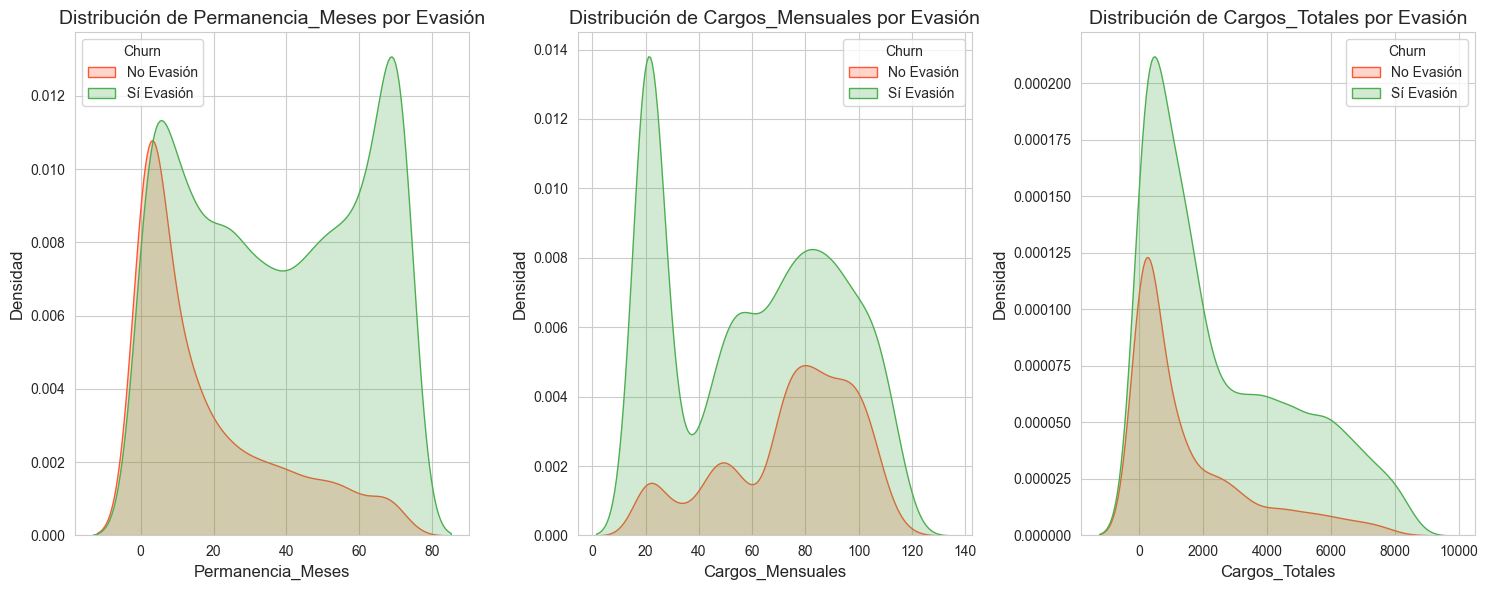

In [23]:
columnas_num = ["Permanencia_Meses", "Cargos_Mensuales", "Cargos_Totales"]

n_cols = len(columnas_num)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 6))

for i, col in enumerate(columnas_num):
    sns.kdeplot(
        data=df,
        x=col,
        hue="Churn",
        fill=True,
        ax=axes[i],
        palette=["#4CAF50", "#FF5733"],
    )

    axes[i].set_title(f"Distribución de {col} por Evasión", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Densidad", fontsize=12)
    axes[i].legend(title="Churn", labels=["No Evasión", "Sí Evasión"])

plt.tight_layout()
plt.show()

In [24]:
df.to_csv("final.csv", sep=',', encoding='utf-8', index=False)

# Informe final

### Introducción

Hay una alta tasa de cancelaciones y se necesita comprender los factores que llevan a la pérdida de clientes para desarrollar estrategias de retención efectivas. Este informe presenta los hallazgos del Análisis Exploratorio de Datos (AED) para identificar los perfiles de clientes con mayor riesgo de evasión.

---

### Limpieza y Tratamiento de Datos

Se importaron librerías necesarias para hacer una importación, limpieza y procesamiento de datos exitoso. Se hizo la conversión de datos a los necesarios, como el hacer **binarias las filas** de ciertas columnas para un mejor procesamiento de datos (e.g., 'Yes'/'No' a 1/0), se verificaron valores nulos y se limpiaron con éxito, se hizo un **aplanamiento de las estructuras de diccionario anidadas** de ciertas columnas para poder tener un mejor procesamiento de datos y tener un Data Frame más legible y limpio (One-Hot Encoding).

---

### Análisis Exploratorio de Datos

#### 1. Distribución General de la Evasión (Churn)

El análisis de la variable objetivo reveló que la base de clientes presenta un **desbalance significativo**:

- **No Evasión:** Aproximadamente el **73.5%** de los clientes.
- **Sí Evasión:** Aproximadamente el **26.5%** de los clientes.

Este desbalance es importante para futuras fases de modelado predictivo, pero confirma que la evasión es una minoría que requiere atención.

#### 2. Evasión por Variables Categóricas y Binarias

Al segmentar la evasión por tipo de servicio y compromiso, se identificaron los principales impulsores de la cancelación:

| Variable                 | Patrón de Evasión (Sí Evasión)                                                                                                                                                     |
| :----------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Tipo de Contrato**     | Los clientes con **Contrato Mes a Mes** tienen, por lejos, la tasa de evasión más alta. Los contratos de Uno y Dos Años actúan como un fuerte factor de retención.                 |
| **Servicio de Internet** | Los clientes con **Internet de Fibra Óptica** muestran una proporción de evasión considerablemente mayor que la de otros servicios, sugiriendo problemas de calidad o experiencia. |
| **Método de Pago**       | El **Pago con Cheque Electrónico** está asociado a la tasa de evasión más alta entre todos los métodos.                                                                            |

#### 3. Evasión por Variables Numéricas Continuas

El análisis de la distribución de variables continuas (utilizando Gráficos de Densidad KDE) reveló patrones en el valor del cliente:

- **Permanencia (Tenure):** El pico de evasión se concentra en clientes con **baja permanencia** (los primeros meses). Esto indica que la fase de _onboarding_ o la satisfacción inicial del servicio son puntos críticos.
- **Cargos Mensuales:** Los clientes con **cargos mensuales altos** (generalmente por encima de $75 USD) muestran una mayor tendencia a evadir.

---

### Conclusiones e Insights

**El Perfil de Mayor Riesgo:** El cliente con mayor riesgo de cancelación es aquel que tiene un **Contrato Mes a Mes**, utiliza el servicio de **Fibra Óptica**, se encuentra en sus **primeros meses de servicio**, y paga mediante **Cheque Electrónico**.

**Factores Clave para la Evasión:**

1.  **Falta de Compromiso:** El contrato mes a mes es la puerta de salida más fácil.
2.  **Fricción Operacional:** La insatisfacción con el servicio de Fibra Óptica y la fricción con el método de Cheque Electrónico son puntos que llevan a la cancelación.
3.  **Vulnerabilidad Inicial:** La mayoría de las pérdidas ocurren al principio del ciclo de vida del cliente.

**Palancas de Retención:** Los servicios de valor añadido como **Soporte Técnico** y **Seguridad Online** demuestran ser excelentes factores de retención.

---

### Recomendaciones

Se sugiere implementar las siguientes acciones estratégicas basadas en los _insights_ del análisis:

1.  **Focalizar la Retención en Meses Iniciales:**

    - Crear un **programa de _onboarding_** intensivo para los clientes de Fibra Óptica durante sus primeros 6 meses, incluyendo seguimiento proactivo para asegurar la calidad del servicio.

2.  **Incentivar el Compromiso Contractual:**

    - Ofrecer descuentos o servicios premium gratuitos para migrar a clientes de contrato Mes a Mes a planes de Un Año, especialmente a aquellos con Cargos Mensuales Altos, ya que representan un alto valor potencial.

3.  **Optimizar Puntos de Fricción:**

    - **Auditar el servicio de Fibra Óptica** para identificar y solucionar problemas de rendimiento.
    - **Mejorar la experiencia de Pago Electrónico** y promocionar métodos de pago automáticos (Tarjeta de Crédito o Transferencia Bancaria) que están asociados con menor evasión.

4.  **Promover Servicios de Valor Añadido:**
    - Incluir obligatoriamente **Soporte Técnico** o **Seguridad Online** en los paquetes de Fibra Óptica, ya que estos servicios han demostrado ser muy eficaces para retener a los clientes.
